In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats
from tqdm import tqdm

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import itertools

In [2]:
try:
    from torch.nn.functional import scaled_dot_product_attention

    SDPA_AVAILABLE = True
except (ImportError, RuntimeError, OSError):
    scaled_dot_product_attention = None
    SDPA_AVAILABLE = False

In [3]:
train_adc_info = pd.read_csv('train_adc_info.csv',
                           index_col='planet_id')

In [4]:
train = np.load('data_train_clean.npy')

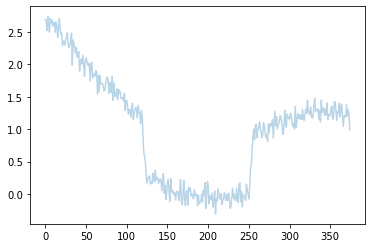

In [5]:
light_curve = train[0].sum(axis=1)
plt.plot(light_curve/light_curve.mean(), '-', alpha=0.3)

In [6]:
train_adc_info.index

Int64Index([    785834,   14485303,   17002355,   24135240,   25070640,
              26372015,   29348276,   33548644,   50637799,   53735941,
            ...
            4205863992, 4228013544, 4246618328, 4247255382, 4247918843,
            4249337798, 4257395405, 4266129805, 4273166473, 4286133832],
           dtype='int64', name='planet_id', length=673)

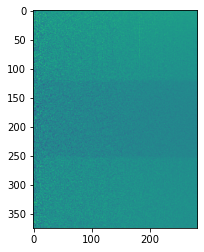

In [7]:
plt.imshow(train[0])

In [40]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os

class CustomDataset(Dataset):
    def __init__(self, data_train, indices, path_labels):
        """
        Args:
            data_train (np.array): Array of shape (673, 187, 282, 32).
            indices (np.array): Array of indices corresponding to the rows in df_labels.
            path_labels (str): Path to the CSV file containing labels.
        """
        self.data_train = torch.tensor(data_train)  # Convert the data to a tensor
        self.data_indices = torch.tensor(indices).long()  # Convert indices to tensor
        self.df_labels = pd.read_csv(path_labels)  # Load df_labels as a pandas DataFrame
        
    def __len__(self):
        # Return the total number of samples
        return len(self.data_indices)

    def __getitem__(self, idx):
        # Get the index from data_indices
        index = self.data_indices[idx].item()  # Convert tensor to Python scalar
        
        # Select the data_train sample corresponding to the index
        data_sample = self.data_train[idx]  # Directly access the data without cloning

        # Select the corresponding label row where the first column matches the index
        label_row = self.df_labels[self.df_labels.iloc[:, 0] == index].iloc[0].values[1:]  # Exclude the first column (index)

        # Convert label_row to a tensor
        label = torch.tensor(label_row).float()

        return data_sample, label

# Example usage
path_ground = 'train_labels.csv'

# Assuming 'train' and 'train_adc_info' are pre-loaded variables containing the training data and indices.
# For example, train could be an array of shape (673, 187, 282, 32), and train_adc_info.index gives the indices.
custom_dataset = CustomDataset(train, train_adc_info.index, path_ground)

# Create a DataLoader to iterate over the dataset
dataloader = DataLoader(custom_dataset, batch_size=32, shuffle=True)  # Pass 'custom_dataset' here

# Iterate through the dataset
for batch_data, batch_labels in dataloader:
    print("Batch Data Shape:", batch_data.shape)  # Should be (batch_size, 187, 282, 32)
    print("Batch Labels Shape:", batch_labels.shape)  # Should be (batch_size, 283)
    break


Batch Data Shape: torch.Size([32, 375, 283])
Batch Labels Shape: torch.Size([32, 283])


In [9]:
import torchvision.models as models

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class SpectralConv_efficient(nn.Module):
    def __init__(self):
        super(SpectralConv_efficient, self).__init__()
        
        # Use EfficientNet (pretrained)
        self.model = models.efficientnet_b0(pretrained=False)
        
        # Adjust the first convolutional layer for 1-channel input instead of 3-channel RGB
        self.model.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

        # Adjust the final fully connected layer to the desired output size
        self.model.classifier[1] = nn.Linear(in_features=1280, out_features=283*2, bias=True)

    def forward(self, x):
        # Apply convolutional layers and fully connected layers
        x = self.model(x)
        
        # Apply a Sigmoid activation after conv layers
        x = torch.sigmoid(x)
        
        return x

In [30]:
# import torch
# import torch.nn as nn
# import torchvision.models as models

# class SpectralConv_resnet(nn.Module):
#     def __init__(self):
#         super(SpectralConv_resnet, self).__init__()
        
#         self.conv1D = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1, bias=False)
        
#         self.model = models.resnet101(pretrained=True)
#         # Adjust the first convolutional layer
#         self.model.conv1 = nn.Conv2d(32, 64, kernel_size=(1, 7), stride=(1, 2), padding=(0, 3), bias=False)
#         # Adjust the maxpool layer
#         self.model.maxpool = nn.MaxPool2d(kernel_size=(1, 3), stride=(1, 2), padding=(0, 1))
#         # Modify the fully connected layer
#         self.model.fc = nn.Linear(in_features=2048, out_features=283*2, bias=True)
    
#     def forward(self, x):
#         x = self.conv1D(x)      # x shape: (batch_size, 32, length)
#         x = x.unsqueeze(2)      # x shape: (batch_size, 32, 1, length)
#         x = self.model(x)       # Pass through ResNet50
#         x = torch.sigmoid(x)
#         return x


In [27]:
# import torch
# import torch.nn as nn
# import torchvision.models as models
# import torch.nn.functional as F

# # Define the SpectralConv model
# class SpectralConv_interpol_efficient(nn.Module):
#     def __init__(self):
#         super(SpectralConv_interpol_efficient, self).__init__()

#         self.conv1D = nn.Conv1d(
#             in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1, bias=False
#         )

#         # Load EfficientNet B0 model
#         self.model = models.efficientnet_b0(pretrained=True)

#         # Modify the first convolutional layer to accept 32 input channels
#         # The first layer is self.model.features[0][0], which is a Conv2d layer
#         self.model.features[0][0] = nn.Conv2d(
#             in_channels=32, out_channels=32, kernel_size=3, stride=2, padding=1, bias=False
#         )

#         # Modify the classifier to output 566 features
#         self.model.classifier[1] = nn.Linear(in_features=1280, out_features=566, bias=True)

#     def forward(self, x):
#         x = self.conv1D(x)  # x shape: (batch_size, 32, length)
#         x = x.unsqueeze(2)  # x shape: (batch_size, 32, 1, length)
#         x = x.transpose(2, 3)  # x shape: (batch_size, 32, length, 1)
        
#         # Upsample or pad x to match EfficientNet's expected input size (e.g., 224x224)
#         x = nn.functional.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        
#         x = self.model(x)  # x shape: (batch_size, 566)
#         x = torch.sigmoid(x)
        
#         return x
    


# # Define the SpectralConv model
# class SpectralConv_padding_efficient(nn.Module):
#     def __init__(self):
#         super(SpectralConv_padding_efficient, self).__init__()

#         self.conv1D = nn.Conv1d(
#             in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1, bias=False
#         )

#         # Load EfficientNet B0 model
#         self.model = models.efficientnet_b0(pretrained=True)

#         # Modify the first convolutional layer to accept 32 input channels
#         # The first layer is self.model.features[0][0], which is a Conv2d layer
#         self.model.features[0][0] = nn.Conv2d(
#             in_channels=32, out_channels=32, kernel_size=3, stride=2, padding=1, bias=False
#         )

#         # Modify the classifier to output 566 features
#         self.model.classifier[1] = nn.Linear(in_features=1280, out_features=566, bias=True)

#     def forward(self, x):
#         x = self.conv1D(x)  # x shape: (batch_size, 32, length)
#         x = x.unsqueeze(2)  # x shape: (batch_size, 32, 1, length)
#         x = x.transpose(2, 3)  # x shape: (batch_size, 32, length, 1)

#         # Calculate padding to match the desired input size
#         desired_height = 224
#         desired_width = 224
#         current_height = x.shape[2]  # Current height (after conv1D and transpose)
#         current_width = x.shape[3]   # Current width (should be 1)

#         # Calculate padding sizes
#         pad_height = desired_height - current_height
#         pad_width = desired_width - current_width

#         # Ensure padding sizes are non-negative
#         if pad_height < 0 or pad_width < 0:
#             raise ValueError("Current tensor size is larger than the desired size.")

#         pad_top = pad_height // 2
#         pad_bottom = pad_height - pad_top
#         pad_left = pad_width // 2
#         pad_right = pad_width - pad_left

#         # Apply padding
#         padding = (pad_left, pad_right, pad_top, pad_bottom)  # (left, right, top, bottom)
#         x = F.pad(x, padding, mode='constant', value=0)

#         x = self.model(x)  # x shape: (batch_size, 566)
#         x = torch.sigmoid(x)
        
#         return x



# # batch_size = 8
# # input_tensor = torch.randn(batch_size, 1, 375)
# # model = SpectralConv()
# # output = model(input_tensor)
# # print("Output shape:", output.shape)  # Should print: Output shape: torch.Size([8, 566])


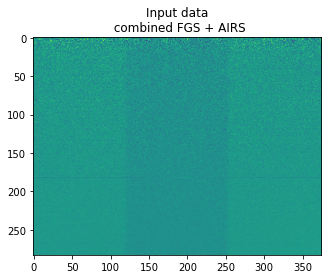

In [28]:
plt.imshow(batch_data[0,:,:].T)
plt.title('Input data\n combined FGS + AIRS')
plt.show()

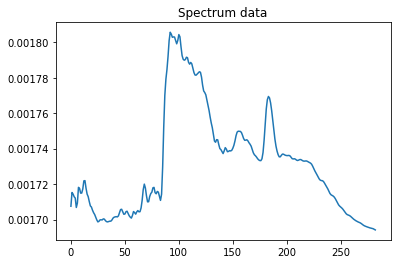

In [39]:
plt.plot(batch_labels[-1].T)
plt.title("Spectrum data")
plt.show()

In [42]:
args = {}

# Training params

args['batch_size'] = 32
args['test_batch_size'] = 10

args['epochs'] = 50*10*2
args['start_epoch'] = 0




# For optimizer
args['lr'] = 1e-5 # LR for B-SNN params
args['lr_decay'] = 1e-6
args['warmup_epochs'] = 10
args['lr_start'] = 1e-5


args['momentum'] = 0.5 # Required for SGD optimiser
args['weight_decay'] = 1e-4 # Weight-decay for ADAM-W optimiser



args['device'] =  torch.device('mps' if torch.backends.mps.is_available() else 'cpu')


In [43]:
import torch
import torch.nn as nn

class ParticipantVisibleError(Exception):
    pass

class ArielLoss(nn.Module):
    def __init__(self, naive_mean, naive_sigma, sigma_true):
        super(ArielLoss, self).__init__()
        self.naive_mean = naive_mean
        self.naive_sigma = naive_sigma
        self.sigma_true = sigma_true

    def forward(self, solution, submission):
        '''
        This is a Gaussian Log Likelihood based loss function. For a submission, which contains the predicted mean (x_hat) and variance (x_hat_std),
        we calculate the Gaussian Log-likelihood (GLL) value compared to the provided ground truth (x). We treat each pair of x_hat,
        x_hat_std as a 1D gaussian, meaning there will be 283 1D gaussian distributions, hence 283 values for each test spectrum,
        the GLL value for one spectrum is the sum of all of them.

        Inputs:
            - solution: Ground Truth spectra (from test set)
                - shape: (nsamples, n_wavelengths)
            - submission: Predicted spectra and errors (from participants)
                - shape: (nsamples, n_wavelengths*2)
        '''
        if torch.any(submission < 0):
            raise ParticipantVisibleError('Negative values in the submission')

        n_wavelengths = 283

        # Predicted mean and standard deviation
        y_pred = submission[:, :n_wavelengths]
        # Set a non-zero minimum sigma pred to prevent division by zero errors
        sigma_pred = torch.clamp(submission[:, n_wavelengths:], min=1e-15)
        y_true = solution

        # Gaussian log-likelihood calculations
        GLL_pred = torch.sum(-0.5 * ((y_true - y_pred) / sigma_pred)**2 - torch.log(sigma_pred) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_true = torch.sum(-0.5 * ((y_true - y_true) / (self.sigma_true * torch.ones_like(y_true)))**2 - torch.log(self.sigma_true * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_mean = torch.sum(-0.5 * ((y_true - self.naive_mean * torch.ones_like(y_true)) / (self.naive_sigma * torch.ones_like(y_true)))**2 - torch.log(self.naive_sigma * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))

        # Score calculation
        submit_score = (GLL_pred - GLL_mean) / (GLL_true - GLL_mean)
        # submit_score = torch.clamp(submit_score, 0.0, 1.0)

        return -submit_score  # Return negative score as loss (since lower loss is better for training)


In [44]:
naive_mean = 0
naive_std = 0
count = 0

for train_batch_idx, (img, y_true) in enumerate(dataloader):

    naive_mean += y_true.mean()
    naive_std += y_true.std()

    count += 1

naive_mean /= count
naive_std /= count
print('Naive Mean: {}'.format(naive_mean))
print('Naive std: {}'.format(naive_std))
    

Naive Mean: 0.0024967386852949858
Naive std: 0.001612421590834856


In [45]:
import time
from torch import Tensor, nn
from typing import Dict, Iterable, Optional, Tuple

In [46]:
import torch
import torch.optim as optim



# Assuming SpectralTransformer and GLLLoss are already defined
specTrans = SpectralConv_efficient() #SpectralConv_resnet() #AstroFCModel(time_steps, num_wavelengths, local_layer_params, final_output_size) #SpectralConv_efficient() #SpectralConv()
specTrans.to(args['device'])

# # Assuming SpectralTransformer and GLLLoss are already defined
# specTrans = SpectralTransformer(dims=dims_tiny)
# specTrans.to(args['device'])



# Optimizer with a smaller learning rate
optimizer = optim.Adam(specTrans.parameters(), lr=args['lr'], betas=(0.9, 0.999), eps=1e-08)

# Use the custom lr scheduler

# criterion =  nn.MSELoss()
# Use the custom lr scheduler

# Quantile loss for two quantiles: 0.1 and 0.9
# quantile_loss_fn = QuantileLoss(quantiles=[0.1, 0.9])

# Training loop
start_time = time.time()

loss_train_arr = []
loss_valid_arr = []

loss_min = np.inf
acc_max = -np.inf


for epoch in range(args['start_epoch'], args['epochs']):
    specTrans.train()

    # Calculate the current learning rate
    # current_lr = lrfn(epoch, num_warmup_steps=N_WARMUP_EPOCHS, lr_max=LR_MAX, num_cycles=0.50)
    #lrfn(current_step, num_warmup_steps, lr_max, num_cycles=0.50, num_training_steps=N_EPOCHS)

    train_acc = 0
    val_acc = 0
    loss_train = 0
    loss_valid = 0
    train_samples = 0
    val_samples = 0
    running_train_loss = 0
    running_eval_loss = 0


        
    for train_batch_idx, (img, y_true) in enumerate(dataloader):

        # Clear gradients for the optimizer before backward pass
        optimizer.zero_grad()
        
        

        img = img.to(torch.float32).to(args['device'])
        y_true = y_true.to(torch.float32).to(args['device'])
        
        # img_permute = img.permute(0,2,1)
        img_unsqueeze = img.unsqueeze(1)
        light_curve = img_unsqueeze.sum(axis=3)/img_unsqueeze.mean()

        # Forward pass
       
        y_pred = specTrans(img_unsqueeze)
        # naive_mean = y_true.mean()
        # naive_std = y_true.std()
       
        train_loss_step = ArielLoss(naive_mean=naive_mean, naive_sigma=naive_std, sigma_true=1e-4)(        
            y_true,
            y_pred)
        
        # Compute loss
        # train_loss_step = quantile_loss_fn(outputs, y_true)

        # train_loss_step = torch.norm(y_true - y_pred, 1)/y_true.shape[0]#criterion(y_pred, y_true) #torch.norm(y_true - y_pred, 1)/y_true.shape[0]

        # Backward pass on the loss, not the score
        train_loss_step.backward()


        # Update the weights
        optimizer.step()
    
        print("Train loss: {}".format(float(train_loss_step)))

        # # If you want to accumulate training loss across the epoch
       
        lr_th_print = optimizer.param_groups[0]["lr"]
        print("LR: {:9f}".format(lr_th_print))

    # Print the accumulated loss per epoch (optional)
    print(f'Epoch {epoch} finished')

    if epoch % 20 == 0:

        chckpt_file_path = 'checkpoint_submission_astrocnn_{}.pth'.format(epoch)
        torch.save(specTrans.state_dict(), chckpt_file_path)

    # You can also save checkpoints and track validation loss/accuracy here if needed

end_time = time.time()
print('Total training time: {:.4f} seconds'.format(end_time - start_time))


/Users/aditya/opt/anaconda3/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/aditya/opt/anaconda3/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Train loss: 1.6214706897735596
LR:  0.000010
Train loss: 1.7626476287841797
LR:  0.000010
Train loss: 1.7650353908538818
LR:  0.000010
Train loss: 1.6383295059204102
LR:  0.000010
Train loss: 1.5614230632781982
LR:  0.000010
Train loss: 1.685214638710022
LR:  0.000010
Train loss: 1.7373546361923218
LR:  0.000010
Train loss: 1.7467563152313232
LR:  0.000010
Train loss: 1.651106834411621
LR:  0.000010
Train loss: 1.8221803903579712
LR:  0.000010
Train loss: 1.7648097276687622
LR:  0.000010
Train loss: 1.6401780843734741
LR:  0.000010
Train loss: 1.6706793308258057
LR:  0.000010
Train loss: 1.8264740705490112
LR:  0.000010
Train loss: 1.6047134399414062
LR:  0.000010
Train loss: 1.633436679840088
LR:  0.000010
Train loss: 1.772226095199585
LR:  0.000010
Train loss: 1.7293074131011963
LR:  0.000010
Train loss: 1.534403920173645
LR:  0.000010
Train loss: 1.5300617218017578
LR:  0.000010
Train loss: 1.7899774312973022
LR:  0.000010
Train loss: 1.837038278579712
LR:  0.000010
Epoch 0 finished

KeyboardInterrupt: 

In [ ]:
light_curve.shape

torch.Size([32, 1, 375])

In [ ]:
print(img.shape)

torch.Size([32, 375, 283])


In [ ]:
light_curve.shape

torch.Size([1, 1, 375])

In [ ]:
img_unsqueeze.shape

torch.Size([1, 1, 375, 283])

In [ ]:
img.shape

torch.Size([1, 375, 283])